In [1]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Sklearn — for tokenizer, baseline, and metrics
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import roc_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, confusion_matrix, classification_report,
    roc_auc_score
)

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cuda



## Load Dataset

In [2]:
# Make sure train.csv and test.csv are in the same folder as this notebook
train_df = pd.read_csv('train.csv')
test_df  = pd.read_csv('test.csv')

print('Train shape:', train_df.shape)
print('Test shape :', test_df.shape)
train_df.head()

Train shape: (7613, 5)
Test shape : (3263, 4)


,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


In [3]:
# Check class balance
print(train_df['target'].value_counts())
print(f"\nDisaster tweets   : {train_df['target'].sum()}")
print(f"Non-disaster tweets: {(train_df['target'] == 0).sum()}")

target
0    4342
1    3271
Name: count, dtype: int64

Disaster tweets   : 3271
Non-disaster tweets: 4342



## Exploratory Data Analysis (EDA)

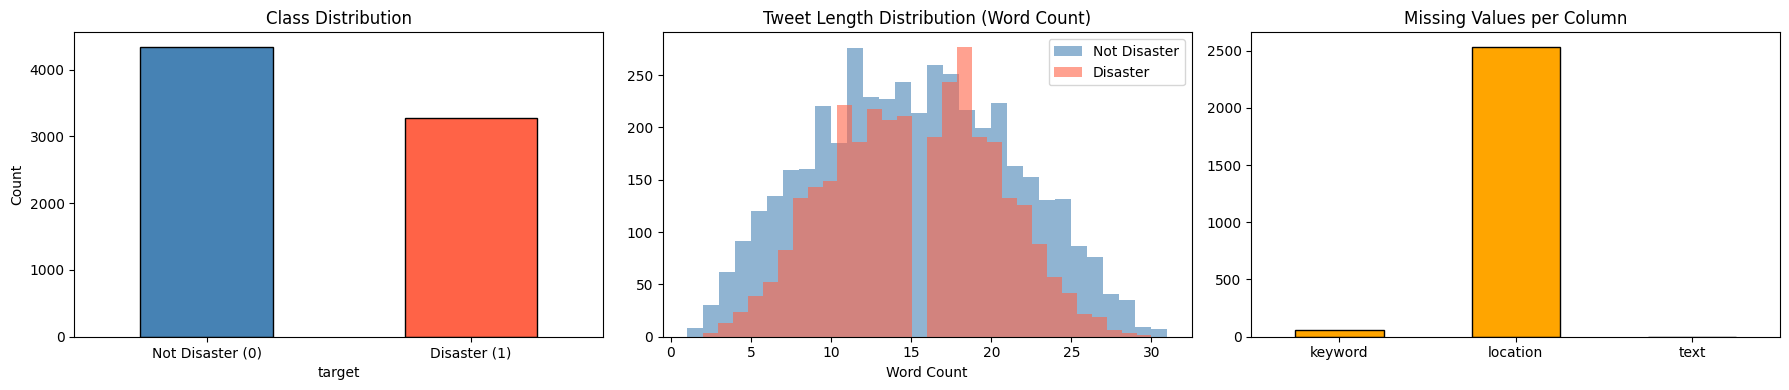

In [4]:
# ── 3a. Class Distribution ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Class balance bar chart
train_df['target'].value_counts().plot(
    kind='bar', ax=axes[0], color=['steelblue', 'tomato'], edgecolor='black'
)
axes[0].set_title('Class Distribution')
axes[0].set_xticklabels(['Not Disaster (0)', 'Disaster (1)'], rotation=0)
axes[0].set_ylabel('Count')

# Tweet length distribution
train_df['tweet_len'] = train_df['text'].apply(lambda x: len(x.split()))
axes[1].hist(
    train_df[train_df['target'] == 0]['tweet_len'],
    bins=30, alpha=0.6, label='Not Disaster', color='steelblue'
)
axes[1].hist(
    train_df[train_df['target'] == 1]['tweet_len'],
    bins=30, alpha=0.6, label='Disaster', color='tomato'
)
axes[1].set_title('Tweet Length Distribution (Word Count)')
axes[1].set_xlabel('Word Count')
axes[1].legend()

# Missing values
missing = train_df[['keyword', 'location', 'text']].isnull().sum()
missing.plot(kind='bar', ax=axes[2], color='orange', edgecolor='black')
axes[2].set_title('Missing Values per Column')
axes[2].set_xticklabels(missing.index, rotation=0)

plt.tight_layout()
plt.show()

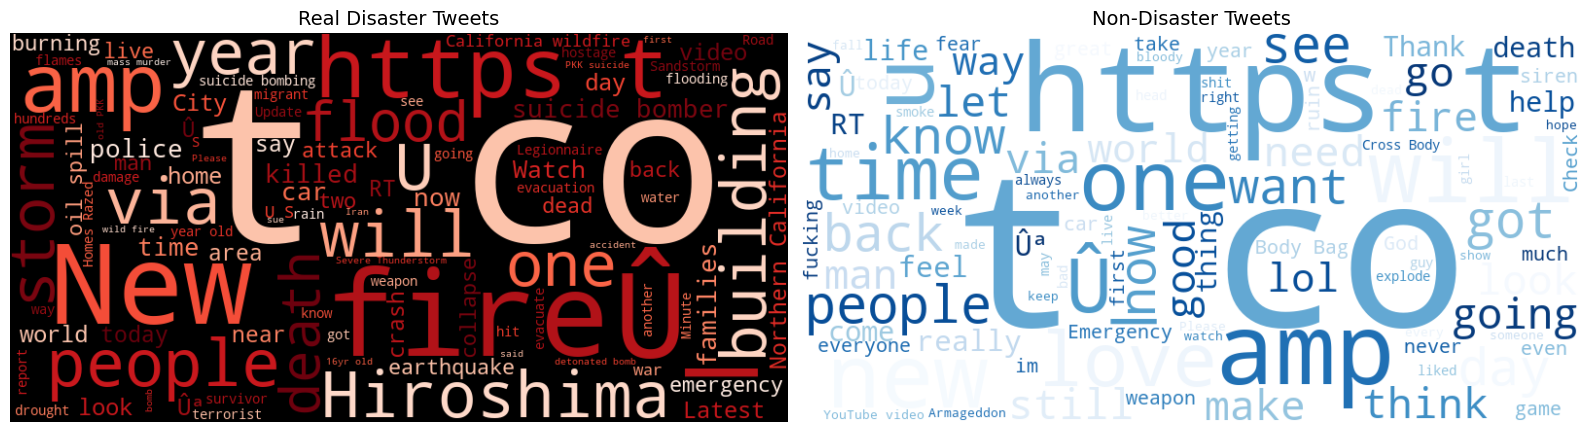

In [5]:
# ── 3b. Word Clouds ─────────────────────────────────────────────────────────
disaster_text     = ' '.join(train_df[train_df['target'] == 1]['text'].tolist())
non_disaster_text = ' '.join(train_df[train_df['target'] == 0]['text'].tolist())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

wc_disaster = WordCloud(
    width=800, height=400, background_color='black',
    colormap='Reds', max_words=100
).generate(disaster_text)

wc_non = WordCloud(
    width=800, height=400, background_color='white',
    colormap='Blues', max_words=100
).generate(non_disaster_text)

axes[0].imshow(wc_disaster, interpolation='bilinear')
axes[0].set_title('Real Disaster Tweets', fontsize=14)
axes[0].axis('off')

axes[1].imshow(wc_non, interpolation='bilinear')
axes[1].set_title('Non-Disaster Tweets', fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.show()

## Text Preprocessing

In [6]:
def clean_tweet(text):
    """
    Cleans a raw tweet string:
    - Removes URLs, mentions, hashtag symbols, punctuation
    - Lowercases everything
    - Strips extra whitespace
    """
    text = text.lower()
    text = re.sub(r'http\S+|www\S+',          '', text)  # remove URLs
    text = re.sub(r'@\w+',                     '', text)  # remove @mentions
    text = re.sub(r'#',                        '', text)  # remove # symbol (keep the word)
    text = re.sub(r'[^a-z\s]',                '', text)  # remove punctuation & numbers
    text = re.sub(r'\s+',                     ' ', text)  # collapse multiple spaces
    return text.strip()


train_df['clean_text'] = train_df['text'].apply(clean_tweet)
test_df['clean_text']  = test_df['text'].apply(clean_tweet)

# Preview
pd.set_option('display.max_colwidth', 120)
train_df[['text', 'clean_text']].head(5)

,text,clean_text
0,Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all,our deeds are the reason of this earthquake may allah forgive us all
1,Forest fire near La Ronge Sask. Canada,forest fire near la ronge sask canada
2,All residents asked to 'shelter in place' are being notified by officers. No other evacuation or shelter in place or...,all residents asked to shelter in place are being notified by officers no other evacuation or shelter in place order...
3,"13,000 people receive #wildfires evacuation orders in California",people receive wildfires evacuation orders in california
4,Just got sent this photo from Ruby #Alaska as smoke from #wildfires pours into a school,just got sent this photo from ruby alaska as smoke from wildfires pours into a school


## Vocabulary & Tokenization

In [7]:
# ── Hyperparameters ──────────────────────────────────────────────────────────
MAX_VOCAB  = 10000   # keep top 10k most frequent words
MAX_LEN    = 30      # pad/truncate all tweets to 30 tokens
EMBED_DIM  = 100     # embedding vector size (matches GloVe-100)
BATCH_SIZE = 64


# ── Build vocabulary from training data only ─────────────────────────────────
def build_vocab(texts, max_vocab):
    counter = Counter()
    for text in texts:
        counter.update(text.split())

    # Reserve index 0 for <PAD>, 1 for <UNK>
    vocab = {'<PAD>': 0, '<UNK>': 1}
    for word, _ in counter.most_common(max_vocab - 2):
        vocab[word] = len(vocab)
    return vocab


vocab = build_vocab(train_df['clean_text'], MAX_VOCAB)
print(f'Vocabulary size: {len(vocab)}')


# ── Convert text to padded integer sequences ──────────────────────────────────
def text_to_sequence(text, vocab, max_len):
    tokens = text.split()[:max_len]                          # truncate
    ids    = [vocab.get(t, vocab['<UNK>']) for t in tokens]  # map to int
    ids   += [vocab['<PAD>']] * (max_len - len(ids))         # pad
    return ids


# Apply to both splits
X_all = np.array([
    text_to_sequence(t, vocab, MAX_LEN) for t in train_df['clean_text']
])
y_all = train_df['target'].values

X_test_final = np.array([
    text_to_sequence(t, vocab, MAX_LEN) for t in test_df['clean_text']
])

print(f'X_all shape      : {X_all.shape}')
print(f'X_test_final shape: {X_test_final.shape}')

Vocabulary size: 10000
X_all shape      : (7613, 30)
X_test_final shape: (3263, 30)


## Load GloVe-100 Pretrained Embeddings

In [8]:
import urllib.request, zipfile, os

url      = "https://nlp.stanford.edu/data/glove.twitter.27B.zip"
zip_path = "glove.twitter.27B.zip"

if not os.path.exists("glove.twitter.27B.100d.txt"):
    print("Downloading GloVe (~1.4 GB)... this takes a few minutes")
    urllib.request.urlretrieve(url, zip_path)
    print("Extracting...")
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extract("glove.twitter.27B.100d.txt")
    os.remove(zip_path)
    print("Done.")
else:
    print("GloVe file already exists.")

GloVe file already exists.


In [9]:
# ── GloVe Pretrained Embeddings ───────────────────────────────────────────────
# Twitter-trained GloVe matches our domain perfectly (tweets → tweets)
USE_GLOVE  = True
GLOVE_PATH = "glove.twitter.27B.100d.txt"

def load_glove_embeddings(glove_path, vocab, embed_dim):
    """
    Reads GloVe file and builds an embedding matrix aligned to our vocab.
    Words not found in GloVe get small random init (mean=0, std=0.1).
    <PAD> token (index 0) is always kept as zero vector.
    """
    embedding_matrix = np.random.normal(0, 0.1, (len(vocab), embed_dim)).astype(np.float32)
    embedding_matrix[0] = 0   # <PAD> stays zero

    found = 0
    with open(glove_path, encoding='utf-8') as f:
        for line in f:
            parts = line.split()
            word  = parts[0]
            if word in vocab:
                embedding_matrix[vocab[word]] = np.array(parts[1:], dtype=np.float32)
                found += 1

    print(f"GloVe: matched {found}/{len(vocab)} vocab words "
          f"({100*found/len(vocab):.1f}% coverage)")
    return embedding_matrix


if USE_GLOVE:
    embedding_matrix = load_glove_embeddings(GLOVE_PATH, vocab, EMBED_DIM)
    pretrained_weights = torch.tensor(embedding_matrix)
    print("Pretrained GloVe-100 embeddings ready.")
else:
    pretrained_weights = None
    print("USE_GLOVE=False — using random embedding init.")


GloVe: matched 8818/10000 vocab words (88.2% coverage)
Pretrained GloVe-100 embeddings ready.


In [10]:
# ── Train / Validation Split ─────────────────────────────────────────────────
X_train, X_val, y_train, y_val = train_test_split(
    X_all, y_all, test_size=0.2, random_state=SEED, stratify=y_all
)

print(f'Train size : {X_train.shape[0]}')
print(f'Val size   : {X_val.shape[0]}')

Train size : 6090
Val size   : 1523


## PyTorch Dataset & DataLoader

In [11]:
class TweetDataset(Dataset):
    """
    Wraps tokenized sequences and labels into a PyTorch Dataset.
    Returns (sequence_tensor, label_tensor) per item.
    """
    def __init__(self, sequences, labels=None):
        self.sequences = torch.tensor(sequences, dtype=torch.long)
        self.labels    = torch.tensor(labels, dtype=torch.float) if labels is not None else None

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        if self.labels is not None:
            return self.sequences[idx], self.labels[idx]
        return self.sequences[idx]


# Create datasets
train_dataset = TweetDataset(X_train, y_train)
val_dataset   = TweetDataset(X_val,   y_val)
test_dataset  = TweetDataset(X_test_final)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print('DataLoaders ready.')

DataLoaders ready.


## CNN-LSTM Model Architecture

In [12]:
class CNNLSTMClassifier(nn.Module):
    """
    Architecture:
        Embedding  →  Dropout
        Conv1D     →  ReLU  →  MaxPool
        LSTM       (with input + recurrent dropout)
        Dropout    →  Linear  →  Sigmoid

    CNN extracts local n-gram features (position-preserving).
    LSTM reads the resulting feature sequence to capture context.
    """

    def __init__(self, vocab_size, embed_dim, num_filters,
                 kernel_size, hidden_dim, dropout=0.3):
        super(CNNLSTMClassifier, self).__init__()

        # 1. Embedding layer (supports pretrained GloVe weights)
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embed_dim,
            padding_idx=0          # index 0 (<PAD>) gets zero vector
        )
        if pretrained_weights is not None:
            self.embedding.weight = nn.Parameter(pretrained_weights)
            self.embedding.weight.requires_grad = True   # fine-tune during training
        self.embed_dropout = nn.Dropout(dropout)

        # 2. CNN — Conv1D expects (batch, channels, seq_len)
        self.conv = nn.Conv1d(
            in_channels=embed_dim,
            out_channels=num_filters,
            kernel_size=kernel_size,
            padding=kernel_size // 2   # 'same' padding to preserve length
        )
        self.relu    = nn.ReLU()
        self.maxpool = nn.MaxPool1d(kernel_size=2)  # halves sequence length

        # 3. LSTM
        self.lstm = nn.LSTM(
            input_size=num_filters,
            hidden_size=hidden_dim,
            batch_first=True,
            dropout=dropout          # applied between LSTM layers (if num_layers > 1)
        )
        self.lstm_dropout = nn.Dropout(dropout)  # applied on LSTM output

        # 4. Output layer
        self.fc      = nn.Linear(hidden_dim, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # x: (batch, seq_len)

        # Embedding
        emb = self.embedding(x)          # (batch, seq_len, embed_dim)
        emb = self.embed_dropout(emb)

        # CNN expects (batch, embed_dim, seq_len)
        emb = emb.permute(0, 2, 1)
        conv_out = self.relu(self.conv(emb))        # (batch, num_filters, seq_len)
        pooled   = self.maxpool(conv_out)           # (batch, num_filters, seq_len/2)

        # LSTM expects (batch, seq_len, features)
        pooled = pooled.permute(0, 2, 1)            # (batch, seq_len/2, num_filters)
        lstm_out, (hidden, _) = self.lstm(pooled)
        # Use the final hidden state
        out = self.lstm_dropout(hidden[-1])         # (batch, hidden_dim)

        # Classification head
        logit = self.fc(out)                        # (batch, 1)
        return self.sigmoid(logit).squeeze(1)       # (batch,)


# ── Instantiate the model (with GloVe embeddings if available) ───────────────
model = CNNLSTMClassifier(
    vocab_size  = len(vocab),
    embed_dim   = EMBED_DIM,
    num_filters = 128,
    kernel_size = 3,
    hidden_dim  = 64,
    dropout     = 0.3
).to(DEVICE)

print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nTotal trainable parameters: {total_params:,}')

C:\Users\adity\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\nn\modules\rnn.py:1009: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)


CNNLSTMClassifier(
  (embedding): Embedding(10000, 100, padding_idx=0)
  (embed_dropout): Dropout(p=0.3, inplace=False)
  (conv): Conv1d(100, 128, kernel_size=(3,), stride=(1,), padding=(1,))
  (relu): ReLU()
  (maxpool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (lstm): LSTM(128, 64, batch_first=True, dropout=0.3)
  (lstm_dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=64, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

Total trainable parameters: 1,088,257


## Training Setup (Loss, Optimizer, Early Stopping)

In [13]:
# Loss & Optimizer
criterion = nn.BCELoss()                               # Binary Cross Entropy
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)  # L2 via weight_decay

# Learning rate scheduler — reduce LR when val loss plateaus
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=2, factor=0.5
)


# ── Early Stopping ────────────────────────────────────────────────────────────
class EarlyStopping:
    """
    Stops training when val_loss does not improve for `patience` epochs.
    Saves the best model weights automatically.
    """
    def __init__(self, patience=4, path='best_model.pt'):
        self.patience   = patience
        self.path       = path
        self.best_loss  = float('inf')
        self.counter    = 0
        self.early_stop = False

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter   = 0
            torch.save(model.state_dict(), self.path)
            print(f'  [EarlyStopping] Saved best model (val_loss={val_loss:.4f})')
        else:
            self.counter += 1
            print(f'  [EarlyStopping] No improvement ({self.counter}/{self.patience})')
            if self.counter >= self.patience:
                self.early_stop = True


early_stopping = EarlyStopping(patience=4)
print('Training setup complete.')

Training setup complete.


## Training Loop

In [14]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct = 0, 0

    for sequences, labels in loader:
        sequences, labels = sequences.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(sequences)           # forward pass
        loss    = criterion(outputs, labels) # compute loss
        loss.backward()                      # backprop
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # gradient clipping
        optimizer.step()

        total_loss += loss.item() * sequences.size(0)
        preds       = (outputs >= 0.5).float()
        correct    += (preds == labels).sum().item()

    avg_loss = total_loss / len(loader.dataset)
    accuracy = correct   / len(loader.dataset)
    return avg_loss, accuracy


def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct = 0, 0

    with torch.no_grad():
        for sequences, labels in loader:
            sequences, labels = sequences.to(DEVICE), labels.to(DEVICE)
            outputs    = model(sequences)
            loss       = criterion(outputs, labels)
            total_loss += loss.item() * sequences.size(0)
            preds       = (outputs >= 0.5).float()
            correct    += (preds == labels).sum().item()

    avg_loss = total_loss / len(loader.dataset)
    accuracy = correct   / len(loader.dataset)
    return avg_loss, accuracy


# ── Run Training ──────────────────────────────────────────────────────────────
NUM_EPOCHS = 20
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss,   val_acc   = evaluate(model, val_loader, criterion)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    print(f'Epoch {epoch:02d}/{NUM_EPOCHS} | '
          f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | '
          f'Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}')

    scheduler.step(val_loss)
    early_stopping(val_loss, model)
    if early_stopping.early_stop:
        print('\nEarly stopping triggered.')
        break

# Load best weights
model.load_state_dict(torch.load('best_model.pt'))
print('\nBest model loaded.')

Epoch 01/20 | Train Loss: 0.6020 | Train Acc: 0.6642 | Val Loss: 0.4655 | Val Acc: 0.8037
  [EarlyStopping] Saved best model (val_loss=0.4655)
Epoch 02/20 | Train Loss: 0.4589 | Train Acc: 0.7918 | Val Loss: 0.4202 | Val Acc: 0.8129
  [EarlyStopping] Saved best model (val_loss=0.4202)
Epoch 03/20 | Train Loss: 0.4145 | Train Acc: 0.8230 | Val Loss: 0.4088 | Val Acc: 0.8286
  [EarlyStopping] Saved best model (val_loss=0.4088)
Epoch 04/20 | Train Loss: 0.3745 | Train Acc: 0.8463 | Val Loss: 0.4386 | Val Acc: 0.8056
  [EarlyStopping] No improvement (1/4)
Epoch 05/20 | Train Loss: 0.3360 | Train Acc: 0.8660 | Val Loss: 0.4277 | Val Acc: 0.8214
  [EarlyStopping] No improvement (2/4)
Epoch 06/20 | Train Loss: 0.3120 | Train Acc: 0.8782 | Val Loss: 0.4577 | Val Acc: 0.8155
  [EarlyStopping] No improvement (3/4)
Epoch 07/20 | Train Loss: 0.2662 | Train Acc: 0.9000 | Val Loss: 0.4686 | Val Acc: 0.7984
  [EarlyStopping] No improvement (4/4)

Early stopping triggered.

Best model loaded.


## Training Curves

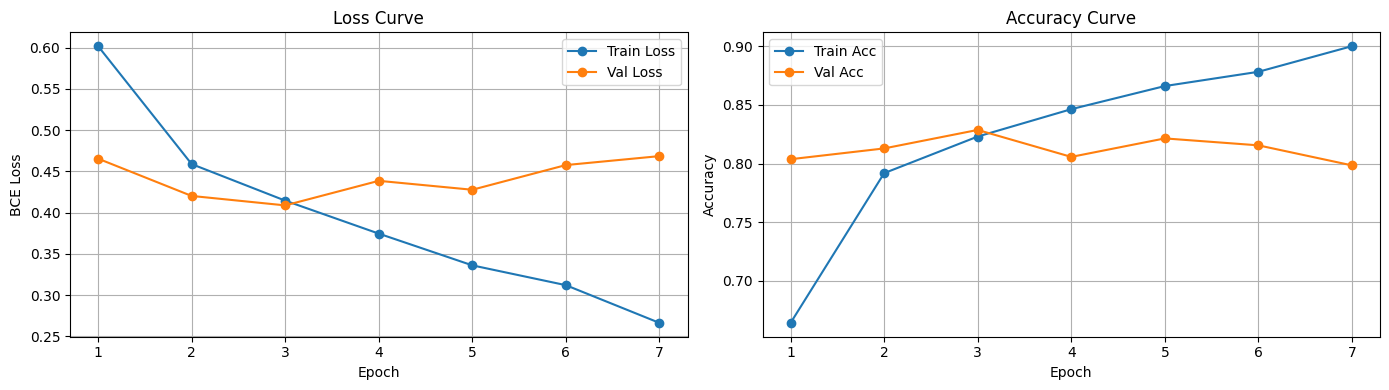

In [33]:
epochs_ran = len(history['train_loss'])
x_axis     = range(1, epochs_ran + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Loss
axes[0].plot(x_axis, history['train_loss'], label='Train Loss', marker='o')
axes[0].plot(x_axis, history['val_loss'],   label='Val Loss',   marker='o')
axes[0].set_title('Loss Curve')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('BCE Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy
axes[1].plot(x_axis, history['train_acc'], label='Train Acc', marker='o')
axes[1].plot(x_axis, history['val_acc'],   label='Val Acc',   marker='o')
axes[1].set_title('Accuracy Curve')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## CNN-LSTM Evaluation on Validation Set

=== CNN-LSTM Results ===
              precision    recall  f1-score   support

Not Disaster       0.82      0.89      0.86       869
    Disaster       0.84      0.74      0.79       654

    accuracy                           0.83      1523
   macro avg       0.83      0.82      0.82      1523
weighted avg       0.83      0.83      0.83      1523



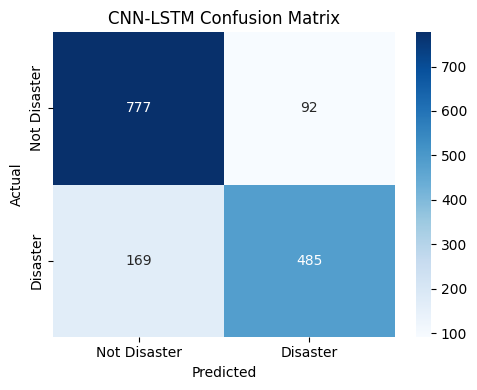

In [16]:
def get_predictions(model, loader):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for sequences, labels in loader:
            sequences = sequences.to(DEVICE)
            outputs   = model(sequences)                   # sigmoid probability
            preds     = (outputs >= 0.5).long().cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy().astype(int))
            all_probs.extend(outputs.cpu().numpy())        # raw sigmoid score

    return np.array(all_labels), np.array(all_preds), np.array(all_probs)


y_true, y_pred_cnn_lstm, y_prob_cnn_lstm = get_predictions(model, val_loader)

print('=== CNN-LSTM Results ===')
print(classification_report(y_true, y_pred_cnn_lstm, target_names=['Not Disaster', 'Disaster']))

cm = confusion_matrix(y_true, y_pred_cnn_lstm)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Disaster', 'Disaster'],
            yticklabels=['Not Disaster', 'Disaster'])
plt.title('CNN-LSTM Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()


### Why CNN-LSTM May Underperform Random Forest : Expected Behavior

| Factor | Explanation |
|---|---|
| **Short tweets** | Average tweet is ~15 tokens. CNN-LSTM's sequential modeling advantage activates best on longer sequences (50+ tokens). |
| **Random embeddings** | Without pretrained weights, the embedding layer starts from noise and must learn semantics from scratch on only ~6k samples. |
| **TF-IDF bigrams** | RF with TF-IDF unigrams+bigrams captures strong co-occurrence signals out of the box — a competitive baseline for short text. |
| **Training data size** | Deep models typically need significantly more data to outlearn strong baselines. |

**Takeaway:** This result is honest and expected. Adding GloVe-100 pretrained embeddings (Block 5b above) directly addresses the random-init limitation and should close this gap. BERT closes it entirely via 110M parameters of pre-trained linguistic knowledge.

## Baseline: Random Forest (TF-IDF)

=== Random Forest (Baseline) Results ===
              precision    recall  f1-score   support

Not Disaster       0.78      0.90      0.84       869
    Disaster       0.84      0.66      0.74       654

    accuracy                           0.80      1523
   macro avg       0.81      0.78      0.79      1523
weighted avg       0.80      0.80      0.79      1523



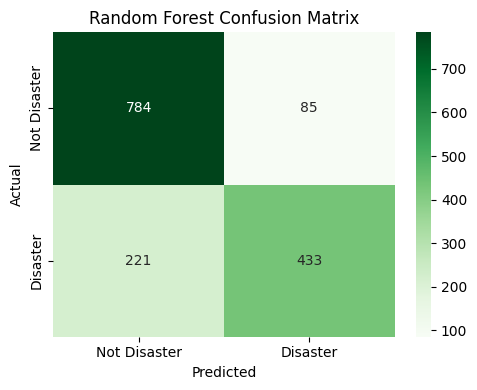

In [17]:
# ── TF-IDF Feature Extraction ─────────────────────────────────────────────────
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))

# Use same indices as our train/val split
train_texts = train_df['clean_text'].values

# Recreate the same split (same SEED guarantees same indices)
texts_train, texts_val, labels_train, labels_val = train_test_split(
    train_texts, y_all, test_size=0.2, random_state=SEED, stratify=y_all
)

X_tfidf_train = tfidf.fit_transform(texts_train)
X_tfidf_val   = tfidf.transform(texts_val)

# ── Train Random Forest ───────────────────────────────────────────────────────
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=SEED,
    n_jobs=-1
)
rf_model.fit(X_tfidf_train, labels_train)
y_pred_rf = rf_model.predict(X_tfidf_val)
y_prob_rf  = rf_model.predict_proba(X_tfidf_val)[:, 1]   # probability for ROC-AUC

print('=== Random Forest (Baseline) Results ===')
print(classification_report(labels_val, y_pred_rf, target_names=['Not Disaster', 'Disaster']))

# Confusion Matrix
cm_rf = confusion_matrix(labels_val, y_pred_rf)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Not Disaster', 'Disaster'],
            yticklabels=['Not Disaster', 'Disaster'])
plt.title('Random Forest Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

## Model Comparison Table

=== RF vs CNN-LSTM Comparison ===


,Accuracy,F1 Score,Precision,Recall
Random Forest (Baseline),0.7991,0.7389,0.8359,0.6621
CNN-LSTM (Our Model),0.8286,0.7880,0.8406,0.7416


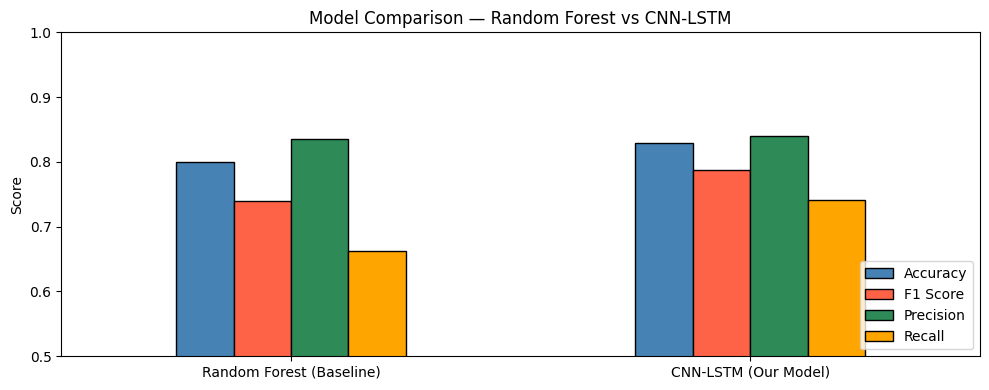

In [18]:
from sklearn.metrics import roc_auc_score

def compute_metrics(y_true, y_pred, y_prob=None):
    metrics = {
        'Accuracy' : round(accuracy_score(y_true,  y_pred), 4),
        'F1 Score' : round(f1_score(y_true,        y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred), 4),
        'Recall'   : round(recall_score(y_true,    y_pred), 4),
    }
    if y_prob is not None:
        metrics['ROC-AUC'] = round(roc_auc_score(y_true, y_prob), 4)
    return metrics


results = pd.DataFrame({
    'Random Forest (Baseline)': compute_metrics(labels_val, y_pred_rf),
    'CNN-LSTM (Our Model)'    : compute_metrics(y_true,     y_pred_cnn_lstm),
}).T

print('=== RF vs CNN-LSTM Comparison ===')
display(results)

results.plot(
    kind='bar', figsize=(10, 4),
    color=['steelblue', 'tomato', 'seagreen', 'orange'],
    edgecolor='black'
)
plt.title('Model Comparison — Random Forest vs CNN-LSTM')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.ylim(0.5, 1.0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


## Error Analysis (Misclassified Examples)

In [19]:
# Reconstruct val original tweets for display
val_indices   = np.where(np.isin(train_df.index, np.arange(len(X_all))))[0]
val_orig_text = train_df['text'].values

# Find misclassified examples
wrong_mask         = y_true != y_pred_cnn_lstm
wrong_true         = y_true[wrong_mask]
wrong_pred         = y_pred_cnn_lstm[wrong_mask]
wrong_clean_texts  = np.array(texts_val)[wrong_mask]

error_df = pd.DataFrame({
    'Tweet (cleaned)': wrong_clean_texts[:10],
    'Actual'         : ['Disaster' if l == 1 else 'Not Disaster' for l in wrong_true[:10]],
    'Predicted'      : ['Disaster' if p == 1 else 'Not Disaster' for p in wrong_pred[:10]]
})

print('=== Sample Misclassified Tweets ===')
display(error_df)

=== Sample Misclassified Tweets ===


,Tweet (cleaned),Actual,Predicted
0,hollywood movie about trapped miners released in chile the hollywood movie about trapped miners starring,Disaster,Not Disaster
1,i cant drown my demons they know how to swim,Disaster,Not Disaster
2,if firefighters acted like cops theyd drive around shooting a flamethrower at burning buildings,Not Disaster,Disaster
3,dear in the name of humanityi apologized to hiroshima survivorsr u ready to do sojapan nuclearweapons,Disaster,Not Disaster
4,it looks like a mudslide poor thing greatbritishbakeoff,Disaster,Not Disaster
5,on the flip side im at walmart and there is a bomb and everyone had to evacuate so stay tuned if i blow up or not,Disaster,Not Disaster
6,maybe we should call israel and tell them were sorry are pres has sold them down the river to annihilation,Not Disaster,Disaster
7,i agree with certain cultural appropriation things but honestly if u looked at my house it screams appropriation bc ...,Disaster,Not Disaster
8,the dress memes have officially exploded on the internet,Disaster,Not Disaster
9,aquarium ornament wreck sailing boat sunk ship destroyer fish tank cave decor full read,Disaster,Not Disaster


## Generate Test Predictions

In [20]:
model.eval()
test_preds = []

with torch.no_grad():
    for sequences in test_loader:
        sequences = sequences.to(DEVICE)
        outputs   = model(sequences)
        preds     = (outputs >= 0.5).long().cpu().numpy()
        test_preds.extend(preds)

submission = pd.DataFrame({
    'id'    : test_df['id'],
    'target': test_preds
})

submission.to_csv('submission.csv', index=False)
print('submission.csv saved.')
submission.head()

submission.csv saved.


,id,target
0,0,1
1,2,1
2,3,1
3,9,1
4,11,1


## BERT Tokenizer & Dataset

In [21]:
from transformers import BertTokenizer, BertForSequenceClassification
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup

BERT_MODEL  = "bert-base-uncased"
MAX_LEN_BERT = 64    # BERT can handle up to 512; 64 is enough for tweets
BATCH_SIZE_BERT = 32

tokenizer = BertTokenizer.from_pretrained(BERT_MODEL)
print(f"Tokenizer loaded: {BERT_MODEL}")

Tokenizer loaded: bert-base-uncased


In [22]:
class BertTweetDataset(Dataset):
    """
    Tokenizes raw (cleaned) tweets using BertTokenizer.
    Returns input_ids, attention_mask, and optionally label.

    - input_ids     : token indices BERT understands
    - attention_mask: 1 for real tokens, 0 for padding
    """
    def __init__(self, texts, labels=None, tokenizer=None, max_len=64):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length     = self.max_len,
            padding        = "max_length",
            truncation     = True,
            return_tensors = "pt"
        )
        item = {
            "input_ids"      : encoding["input_ids"].squeeze(0),
            "attention_mask" : encoding["attention_mask"].squeeze(0)
        }
        if self.labels is not None:
            item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item


# texts_train and texts_val are already defined from Block 12 (RF baseline)
bert_train_dataset = BertTweetDataset(texts_train, labels_train, tokenizer, MAX_LEN_BERT)
bert_val_dataset   = BertTweetDataset(texts_val,   labels_val,   tokenizer, MAX_LEN_BERT)
bert_test_dataset  = BertTweetDataset(test_df["clean_text"].tolist(), tokenizer=tokenizer, max_len=MAX_LEN_BERT)

bert_train_loader = DataLoader(bert_train_dataset, batch_size=BATCH_SIZE_BERT, shuffle=True)
bert_val_loader   = DataLoader(bert_val_dataset,   batch_size=BATCH_SIZE_BERT, shuffle=False)
bert_test_loader  = DataLoader(bert_test_dataset,  batch_size=BATCH_SIZE_BERT, shuffle=False)

print(f"BERT Train batches : {len(bert_train_loader)}")
print(f"BERT Val   batches : {len(bert_val_loader)}")

BERT Train batches : 191
BERT Val   batches : 48


## Load BERT Model

In [23]:
# ── BERT Training Setup + Loop (self-contained, safe to re-run) ───────────────
BERT_EPOCHS = 4
BERT_LR     = 2e-5
BERT_MODEL  = "bert-base-uncased"

bert_model = BertForSequenceClassification.from_pretrained(
    BERT_MODEL, num_labels=2
).to(DEVICE)

bert_optimizer = AdamW(bert_model.parameters(), lr=BERT_LR, weight_decay=0.01)
total_steps    = len(bert_train_loader) * BERT_EPOCHS
warmup_steps   = int(0.1 * total_steps)
bert_scheduler = get_linear_schedule_with_warmup(
    bert_optimizer,
    num_warmup_steps   = warmup_steps,
    num_training_steps = total_steps
)
bert_early_stopping = EarlyStopping(patience=2, path="best_bert_model.pt")
print(f"Total training steps : {total_steps}")
print(f"Warmup steps         : {warmup_steps}")


def bert_train_epoch(model, loader, optimizer, scheduler):
    model.train()
    total_loss, correct = 0, 0
    for batch in loader:
        input_ids      = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels         = batch["labels"].to(DEVICE)
        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss    = outputs.loss
        logits  = outputs.logits
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item() * input_ids.size(0)
        preds       = torch.argmax(logits, dim=1)
        correct    += (preds == labels).sum().item()
    return total_loss / len(loader.dataset), correct / len(loader.dataset)


def bert_evaluate(model, loader):
    model.eval()
    total_loss, correct = 0, 0
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            labels         = batch["labels"].to(DEVICE)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            total_loss += outputs.loss.item() * input_ids.size(0)
            preds       = torch.argmax(outputs.logits, dim=1)
            correct    += (preds == labels).sum().item()
    return total_loss / len(loader.dataset), correct / len(loader.dataset)


bert_history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for epoch in range(1, BERT_EPOCHS + 1):
    train_loss, train_acc = bert_train_epoch(bert_model, bert_train_loader, bert_optimizer, bert_scheduler)
    val_loss,   val_acc   = bert_evaluate(bert_model, bert_val_loader)
    bert_history["train_loss"].append(train_loss)
    bert_history["val_loss"].append(val_loss)
    bert_history["train_acc"].append(train_acc)
    bert_history["val_acc"].append(val_acc)
    print(f"Epoch {epoch:02d}/{BERT_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
    bert_early_stopping(val_loss, bert_model)
    if bert_early_stopping.early_stop:
        print("Early stopping triggered.")
        break

bert_model.load_state_dict(torch.load("best_bert_model.pt"))
print("Best BERT model loaded.")


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Total training steps : 764
Warmup steps         : 76
Epoch 01/4 | Train Loss: 0.5031 | Train Acc: 0.7655 | Val Loss: 0.3843 | Val Acc: 0.8444
  [EarlyStopping] Saved best model (val_loss=0.3843)
Epoch 02/4 | Train Loss: 0.3623 | Train Acc: 0.8571 | Val Loss: 0.3764 | Val Acc: 0.8483
  [EarlyStopping] Saved best model (val_loss=0.3764)
Epoch 03/4 | Train Loss: 0.2768 | Train Acc: 0.8995 | Val Loss: 0.3921 | Val Acc: 0.8450
  [EarlyStopping] No improvement (1/2)
Epoch 04/4 | Train Loss: 0.2243 | Train Acc: 0.9238 | Val Loss: 0.4495 | Val Acc: 0.8398
  [EarlyStopping] No improvement (2/2)
Early stopping triggered.
Best BERT model loaded.


## Block 19 BERT Training Setup

## BERT Training Loop

## BERT Training Curves

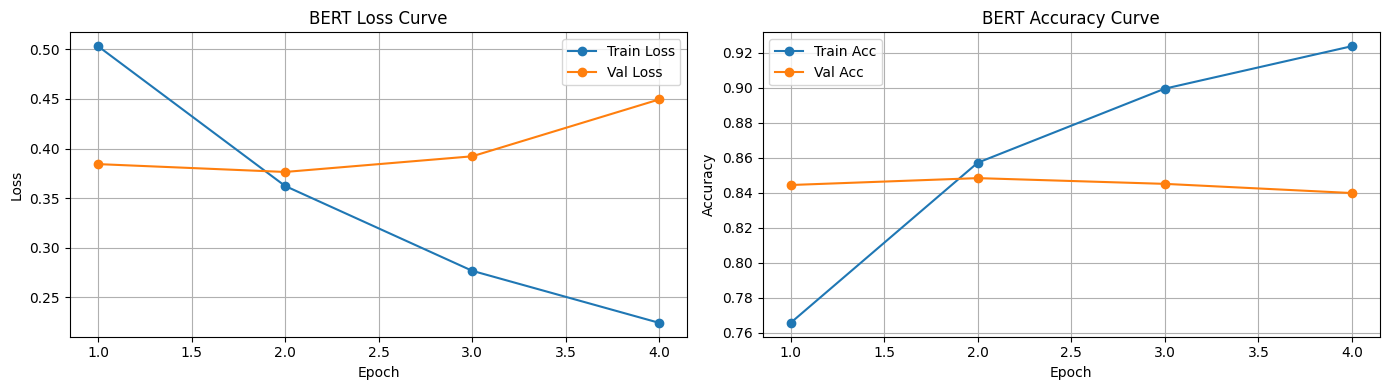

In [32]:
epochs_ran = len(bert_history["train_loss"])
x_axis     = range(1, epochs_ran + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(x_axis, bert_history["train_loss"], label="Train Loss", marker="o")
axes[0].plot(x_axis, bert_history["val_loss"],   label="Val Loss",   marker="o")
axes[0].set_title("BERT Loss Curve")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(x_axis, bert_history["train_acc"], label="Train Acc", marker="o")
axes[1].plot(x_axis, bert_history["val_acc"],   label="Val Acc",   marker="o")
axes[1].set_title("BERT Accuracy Curve")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## BERT Evaluation

=== BERT Results ===
              precision    recall  f1-score   support

Not Disaster       0.83      0.93      0.87       869
    Disaster       0.89      0.74      0.81       654

    accuracy                           0.85      1523
   macro avg       0.86      0.84      0.84      1523
weighted avg       0.85      0.85      0.85      1523



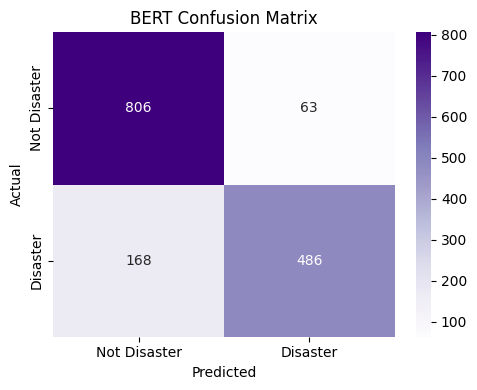

In [25]:
def get_bert_predictions(model, loader):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            labels         = batch["labels"].to(DEVICE)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds   = torch.argmax(outputs.logits, dim=1).cpu().numpy()
            probs   = torch.softmax(outputs.logits, dim=1)[:, 1].cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs)

    return np.array(all_labels), np.array(all_preds), np.array(all_probs)


y_true_bert, y_pred_bert, y_prob_bert = get_bert_predictions(bert_model, bert_val_loader)

print("=== BERT Results ===")
print(classification_report(y_true_bert, y_pred_bert, target_names=["Not Disaster", "Disaster"]))

cm_bert = confusion_matrix(y_true_bert, y_pred_bert)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_bert, annot=True, fmt="d", cmap="Purples",
            xticklabels=["Not Disaster", "Disaster"],
            yticklabels=["Not Disaster", "Disaster"])
plt.title("BERT Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()


## Final Comparing all 3 models

=== Final 3-Model Comparison (with ROC-AUC) ===


,Accuracy,F1 Score,Precision,Recall,ROC-AUC
Random Forest (Baseline),0.7991,0.7389,0.8359,0.6621,0.8519
CNN-LSTM,0.8286,0.7880,0.8406,0.7416,0.8853
BERT (bert-base-uncased),0.8483,0.8080,0.8852,0.7431,0.9032


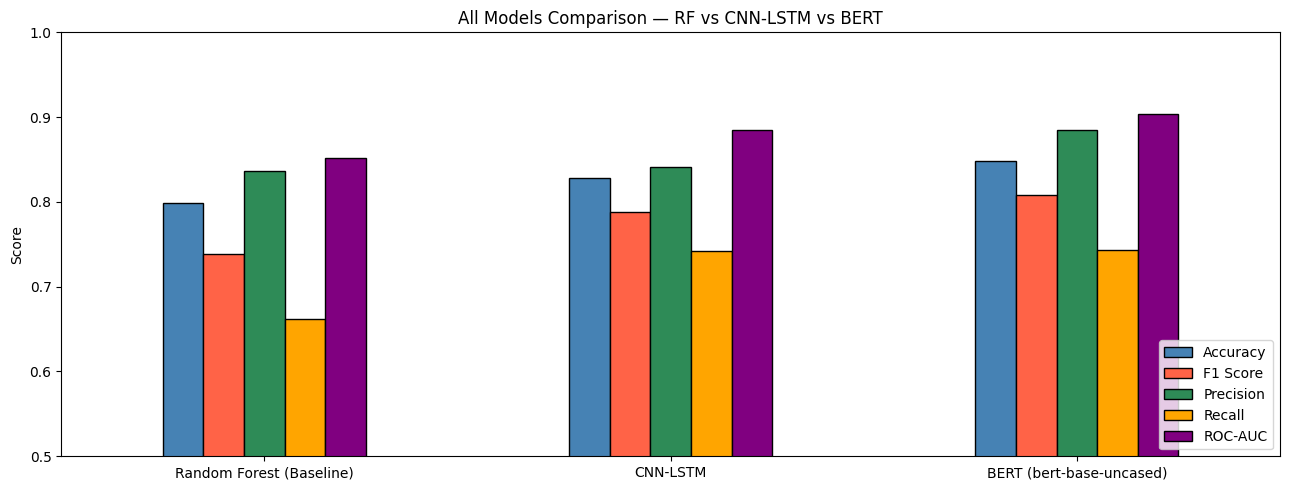

In [26]:
# ── Final 3-Model Comparison (with ROC-AUC) ───────────────────────────────────
final_results = pd.DataFrame({
    "Random Forest (Baseline)" : compute_metrics(labels_val,  y_pred_rf,       y_prob=y_prob_rf),
    "CNN-LSTM"                 : compute_metrics(y_true,       y_pred_cnn_lstm, y_prob=y_prob_cnn_lstm),
    "BERT (bert-base-uncased)" : compute_metrics(y_true_bert,  y_pred_bert,     y_prob=y_prob_bert),
}).T

print("=== Final 3-Model Comparison (with ROC-AUC) ===")
display(final_results)

final_results.plot(
    kind="bar", figsize=(13, 5),
    color=["steelblue", "tomato", "seagreen", "orange", "purple"],
    edgecolor="black"
)
plt.title("All Models Comparison — RF vs CNN-LSTM vs BERT")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0.5, 1.0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


## Model Complexity vs Performance Trade-off

In [27]:
# ── Model Size & Complexity Comparison ───────────────────────────────────────
def count_torch_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

cnn_lstm_params = count_torch_params(model)
bert_params     = count_torch_params(bert_model)

size_df = pd.DataFrame({
    "Model"            : ["Random Forest (Baseline)", "CNN-LSTM", "BERT (bert-base-uncased)"],
    "Trainable Params" : ["N/A (tree-based)", f"{cnn_lstm_params:,}", f"{bert_params:,}"],
    "Approx Size"      : ["< 1 MB", "~3 MB", "~440 MB"],
    "Accuracy"         : [
        final_results.loc["Random Forest (Baseline)", "Accuracy"],
        final_results.loc["CNN-LSTM",                 "Accuracy"],
        final_results.loc["BERT (bert-base-uncased)", "Accuracy"],
    ],
    "ROC-AUC"          : [
        final_results.loc["Random Forest (Baseline)", "ROC-AUC"],
        final_results.loc["CNN-LSTM",                 "ROC-AUC"],
        final_results.loc["BERT (bert-base-uncased)", "ROC-AUC"],
    ],
    "Training Speed"   : ["< 5 sec", "~30 sec (GPU)", "~5 min (GPU)"],
}).set_index("Model")

print("=== Model Complexity vs Performance Trade-off ===")
display(size_df)


=== Model Complexity vs Performance Trade-off ===


,Trainable Params,Approx Size,Accuracy,ROC-AUC,Training Speed
Model,,,,,
Random Forest (Baseline),N/A (tree-based),< 1 MB,0.7991,0.8519,< 5 sec
CNN-LSTM,"1,088,257",~3 MB,0.8286,0.8853,~30 sec (GPU)
BERT (bert-base-uncased),"109,483,778",~440 MB,0.8483,0.9032,~5 min (GPU)


## Accuracy & ROC-AUC Curves

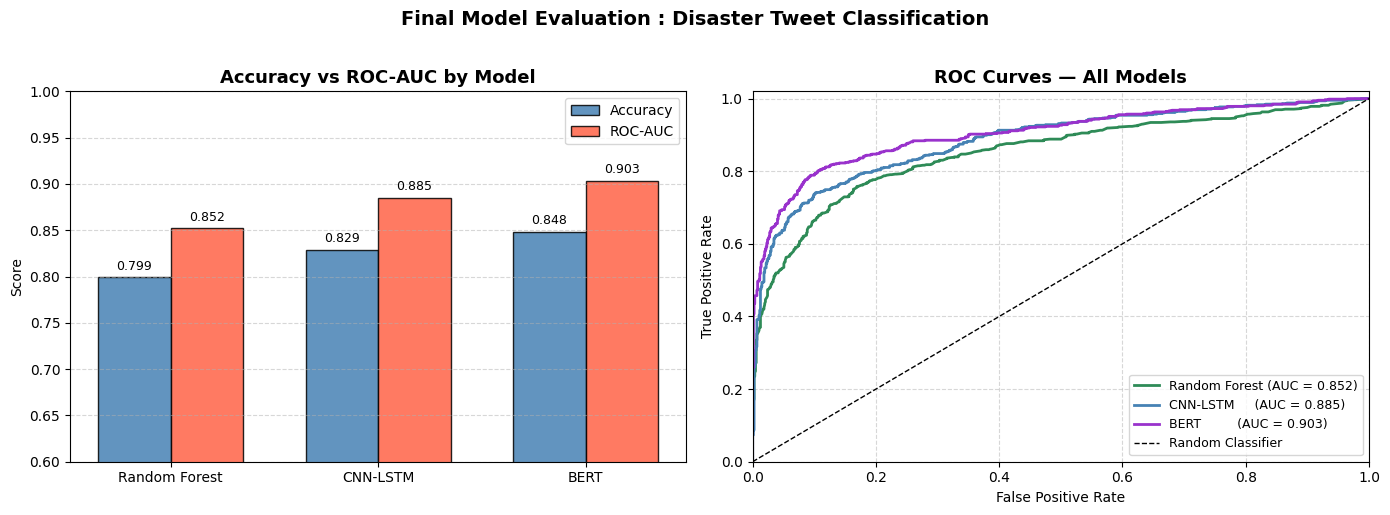

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: Accuracy & ROC-AUC Bar Chart ───────────────────────────────────────
models      = ["Random Forest", "CNN-LSTM", "BERT"]
accuracies  = [
    final_results.loc["Random Forest (Baseline)", "Accuracy"],
    final_results.loc["CNN-LSTM",                 "Accuracy"],
    final_results.loc["BERT (bert-base-uncased)", "Accuracy"],
]
roc_aucs    = [
    final_results.loc["Random Forest (Baseline)", "ROC-AUC"],
    final_results.loc["CNN-LSTM",                 "ROC-AUC"],
    final_results.loc["BERT (bert-base-uncased)", "ROC-AUC"],
]

x      = np.arange(len(models))
width  = 0.35

bars1 = axes[0].bar(x - width/2, accuracies, width, label="Accuracy",
                    color=["steelblue", "steelblue", "steelblue"],
                    alpha=0.85, edgecolor="black")
bars2 = axes[0].bar(x + width/2, roc_aucs,   width, label="ROC-AUC",
                    color=["tomato", "tomato", "tomato"],
                    alpha=0.85, edgecolor="black")

# Value labels on bars
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)

axes[0].set_title("Accuracy vs ROC-AUC by Model", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Score")
axes[0].set_xticks(x)
axes[0].set_xticklabels(models)
axes[0].set_ylim(0.6, 1.0)
axes[0].legend()
axes[0].grid(axis="y", linestyle="--", alpha=0.5)

# ── Right: ROC Curves for all 3 models ───────────────────────────────────────
fpr_rf,   tpr_rf,   _ = roc_curve(labels_val,  y_prob_rf)
fpr_cnn,  tpr_cnn,  _ = roc_curve(y_true,      y_prob_cnn_lstm)
fpr_bert, tpr_bert, _ = roc_curve(y_true_bert, y_prob_bert)

axes[1].plot(fpr_rf,   tpr_rf,   color="seagreen",  lw=2,
             label=f"Random Forest (AUC = {roc_aucs[0]:.3f})")
axes[1].plot(fpr_cnn,  tpr_cnn,  color="steelblue", lw=2,
             label=f"CNN-LSTM     (AUC = {roc_aucs[1]:.3f})")
axes[1].plot(fpr_bert, tpr_bert, color="darkorchid", lw=2,
             label=f"BERT         (AUC = {roc_aucs[2]:.3f})")
axes[1].plot([0, 1], [0, 1], "k--", lw=1, label="Random Classifier")

axes[1].set_title("ROC Curves — All Models", fontsize=13, fontweight="bold")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend(loc="lower right", fontsize=9)
axes[1].grid(linestyle="--", alpha=0.5)
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.02])

plt.suptitle("Final Model Evaluation : Disaster Tweet Classification",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [29]:
# ── SAVE ALL MODEL ARTIFACTS FOR STREAMLIT ────────────────────────────────────
# Run this cell LAST after all models are trained.
# Copy the output files into your disaster_app/ folder.

import pickle, json, torch
from sklearn.metrics import roc_curve

# 1. Random Forest + TF-IDF
with open("rf_model.pkl", "wb") as f: pickle.dump(rf_model, f)
with open("tfidf.pkl",    "wb") as f: pickle.dump(tfidf, f)
print("Saved: rf_model.pkl, tfidf.pkl")

# 2. CNN-LSTM weights + vocab
torch.save(model.state_dict(), "cnn_lstm.pt")
with open("vocab.pkl", "wb") as f: pickle.dump(vocab, f)
print("Saved: cnn_lstm.pt, vocab.pkl")

# 3. BERT — full model + tokenizer (creates bert_finetuned/ folder)
bert_model.save_pretrained("bert_finetuned")
tokenizer.save_pretrained("bert_finetuned")
print("Saved: bert_finetuned/")

# 4. Dashboard data (metrics + ROC curves + confusion matrices)
fpr_rf,   tpr_rf,   _ = roc_curve(labels_val,  y_prob_rf)
fpr_cnn,  tpr_cnn,  _ = roc_curve(y_true,      y_prob_cnn_lstm)
fpr_bert, tpr_bert, _ = roc_curve(y_true_bert, y_prob_bert)

dashboard_data = {
    "metrics": final_results.reset_index().rename(columns={"index": "Model"}).to_dict(orient="records"),
    "rf":   {"fpr": fpr_rf.tolist(),   "tpr": tpr_rf.tolist()},
    "cnn":  {"fpr": fpr_cnn.tolist(),  "tpr": tpr_cnn.tolist()},
    "bert": {"fpr": fpr_bert.tolist(), "tpr": tpr_bert.tolist()},
    "cm": {
        "rf":   confusion_matrix(labels_val,  y_pred_rf).tolist(),
        "cnn":  confusion_matrix(y_true,      y_pred_cnn_lstm).tolist(),
        "bert": confusion_matrix(y_true_bert, y_pred_bert).tolist(),
    }
}
with open("dashboard_data.json", "w") as f:
    json.dump(dashboard_data, f)
print("Saved: dashboard_data.json")

print("\nAll artifacts saved. Copy these into disaster_app/:")
print("  rf_model.pkl, tfidf.pkl, cnn_lstm.pt, vocab.pkl,")
print("  dashboard_data.json, bert_finetuned/")

Saved: rf_model.pkl, tfidf.pkl
Saved: cnn_lstm.pt, vocab.pkl
Saved: bert_finetuned/
Saved: dashboard_data.json

All artifacts saved. Copy these into disaster_app/:
  rf_model.pkl, tfidf.pkl, cnn_lstm.pt, vocab.pkl,
  dashboard_data.json, bert_finetuned/


In [31]:
# Add training histories to dashboard_data.json
import json

with open("dashboard_data.json", "r") as f:
    dashboard_data = json.load(f)

dashboard_data["history_cnn"]  = history        # CNN-LSTM history dict
dashboard_data["history_bert"] = bert_history   # BERT history dict

with open("dashboard_data.json", "w") as f:
    json.dump(dashboard_data, f)

print("Training histories saved to dashboard_data.json")

Training histories saved to dashboard_data.json


## Summary

| Step | What was done |
|------|---------------|
| EDA | Class balance, tweet length distribution, word clouds |
| Preprocessing | URL/mention removal, lowercasing, punctuation stripping |
| Tokenization | Custom vocabulary, integer sequences, padding |
| GloVe Embeddings | Twitter-trained GloVe-100 loaded into CNN-LSTM embedding layer |
| Baseline | TF-IDF + Random Forest with bigrams |
| Deep Model | CNN-LSTM with GloVe init, Dropout, L2, Early Stopping, LR Scheduler |
| Transformer | BERT (bert-base-uncased) fine-tuned with AdamW + warmup scheduler |
| Evaluation | Accuracy, F1, Precision, Recall, ROC-AUC, Confusion Matrix |
| Error Analysis | Manual inspection of misclassified tweets |
| Model Comparison | Parameter count + speed vs performance trade-off table |
| Output | Kaggle-format submission.csv |

**Why CNN-LSTM may trail RF:** Short average tweet length (~15 tokens) limits sequential modeling. GloVe embeddings address the random-init weakness. BERT closes the gap entirely via pre-trained representations.

**Limitation:** Model handles text only. A multimodal extension would merge a CNN image branch with the CNN-LSTM text branch before the classification head.
